# 1. Data Ingestion

In this section I will create the setup for the project, alongside creating the process of ingestion of relevant financial data.
We will also create a simple light-weight data pipeline to clean this data and represent it.

## 1.1 Set file path

Here I set the file path to ensure the Jupyter notebook can be run on any system, no hardset file paths.

In [1]:
import sys
from pathlib import Path

# Try to locate the project root by looking for a directory that contains 'src'
cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent, cwd.parent.parent]

PROJECT_ROOT = None
for path in candidate_roots:
    if (path / "src").exists():
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not find project root containing 'src'.")

# Add project root to Python path so 'from src...' imports work
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root set to: {PROJECT_ROOT}")


Project root set to: C:\Users\User\git\personal_projects\market-regimes-trading-signals\market-regimes-trading-signals


## 1.2 Data Configuration

Here I imported our config file and set these to our local DataConfig to be used within the notebook.
I then verify the data is loaded and of the correct form by revealing the head and tail.

In [2]:
from src.config import (
    PROJECT_ROOT,
    DATA_RAW_DIR,
    DATA_PROCESSED_DIR,
    TICKERS,
    START_DATE,
    END_DATE,
)
from src.data import DataConfig, build_and_save_market_dataset

In [3]:
config = DataConfig(
    tickers=TICKERS,
    start_date=START_DATE,
    end_date=END_DATE,
    raw_dir=DATA_RAW_DIR,
    processed_dir=DATA_PROCESSED_DIR,
)

df = build_and_save_market_dataset(config)
df.head()

,spy_close,spy_adj_close,spy_volume,vix_close,vix_adj_close,tnx_close,tnx_adj_close
date,,,,,,,
2012-01-03,127.500000,99.312195,193697900,22.969999,22.969999,1.960,1.960
2012-01-04,127.699997,99.467972,127186500,22.219999,22.219999,1.995,1.995
2012-01-05,128.039993,99.732819,173895000,21.480000,21.480000,1.993,1.993
2012-01-06,127.709999,99.475784,148050000,20.629999,20.629999,1.961,1.961
2012-01-09,128.020004,99.717239,99530200,21.070000,21.070000,1.960,1.960


Here I print the latest 5 rows, showing our most recent date of information.

In [4]:
df.tail()

,spy_close,spy_adj_close,spy_volume,vix_close,vix_adj_close,tnx_close,tnx_adj_close
date,,,,,,,
2026-03-23,655.380005,655.380005,134802700,26.150000,26.150000,4.334,4.334
2026-03-24,653.179993,653.179993,96457500,26.950001,26.950001,4.392,4.392
2026-03-25,656.820007,656.820007,90653800,25.330000,25.330000,4.328,4.328
2026-03-26,645.090027,645.090027,96494400,27.440001,27.440001,4.416,4.416
2026-03-27,634.090027,634.090027,102725900,31.049999,31.049999,4.440,4.440


## 1.3 Data Representation

Here I plot the SPY Adjusted Close, the VIX Close and the 10Y Treasury Yield proxy together to initially model their relationship together.

From below we can see a strong upwards trend for the SPY adjusted close, alongside a strong dip coinciding with the peak of the VIX Close at around 2020. It is worth noting here that this also aligns with a low point in the 10Y Treasury Yield Proxy.

array([<Axes: title={'center': 'SPY Adjusted Close'}, xlabel='date'>,
       <Axes: title={'center': 'VIX Close'}, xlabel='date'>,
       <Axes: title={'center': '10Y Treasury Yield Proxy'}, xlabel='date'>],
      dtype=object)

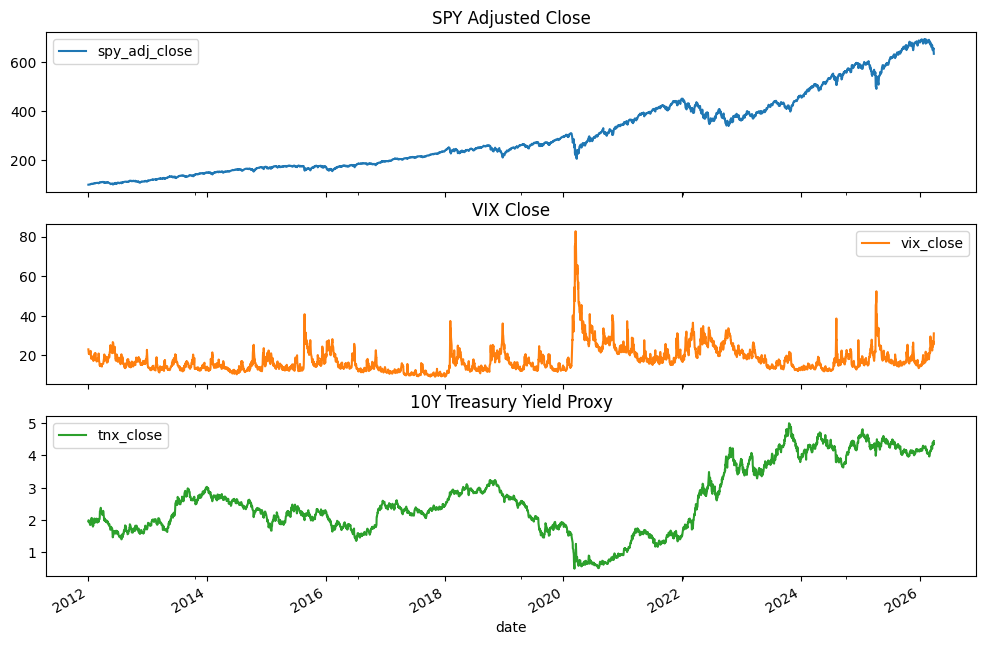

In [5]:
df[["spy_adj_close", "vix_close", "tnx_close"]].plot(
    subplots=True,
    figsize=(12, 8),
    title=["SPY Adjusted Close", "VIX Close", "10Y Treasury Yield Proxy"],
)

# 2. Feature Engineering

In this section, I construct a set of interpretable features designed to capture
the key dimensions of market behaviour relevant for regime classification.

Rather than using complex models or large feature sets, I focus on a small number
of variables that reflect:

- **direction (trend)** of the market  
- **instability (volatility)**  
- **market stress (drawdown)**  
- **broader risk context (VIX and interest rates)**  

The goal is not to predict short-term price movements, but to build a structured
representation of market conditions that can later be used to define regimes.

In [6]:
from src.features import (
    add_all_features,
    get_available_feature_columns,
    summarize_feature_coverage,
    drop_feature_warmup_rows,
)

features_df = add_all_features(df).copy()

print(f"Feature dataframe shape: {features_df.shape}")
features_df.head()

Feature dataframe shape: (3579, 17)


,spy_close,spy_adj_close,spy_volume,vix_close,vix_adj_close,tnx_close,tnx_adj_close,spy_ret_1d,spy_ma_50,spy_ma_200,spy_trend_signal,spy_rv_20,spy_rv_60,spy_drawdown_252,vix_level,vix_change_20,tnx_change_20
date,,,,,,,,,,,,,,,,,
2012-01-03,127.500000,99.312195,193697900,22.969999,22.969999,1.960,1.960,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,22.969999,NaN,NaN
2012-01-04,127.699997,99.467972,127186500,22.219999,22.219999,1.995,1.995,0.001569,NaN,NaN,NaN,NaN,NaN,0.000000,22.219999,NaN,NaN
2012-01-05,128.039993,99.732819,173895000,21.480000,21.480000,1.993,1.993,0.002663,NaN,NaN,NaN,NaN,NaN,0.000000,21.480000,NaN,NaN
2012-01-06,127.709999,99.475784,148050000,20.629999,20.629999,1.961,1.961,-0.002577,NaN,NaN,NaN,NaN,NaN,-0.002577,20.629999,NaN,NaN
2012-01-09,128.020004,99.717239,99530200,21.070000,21.070000,1.960,1.960,0.002427,NaN,NaN,NaN,NaN,NaN,-0.000156,21.070000,NaN,NaN


## 2.1 Feature Overview

The first version of the feature set includes:

- **Returns**
  - `spy_ret_1d`: daily percentage return

- **Trend**
  - `spy_ma_50`: 50-day moving average
  - `spy_ma_200`: 200-day moving average
  - `spy_trend_signal`: indicator for whether the short-term trend is above the long-term trend

- **Volatility**
  - `spy_rv_20`: short-term realized volatility (20 days)
  - `spy_rv_60`: medium-term realized volatility (60 days)

- **Drawdown**
  - `spy_drawdown_252`: distance from the rolling one-year peak

- **Macro / Risk Proxies**
  - `vix_level`: implied volatility index
  - `vix_change_20`: change in market fear over 20 days
  - `tnx_change_20`: change in interest rates over 20 days

These features are intentionally simple and interpretable, which is important for
understanding and explaining regime behaviour.

In [7]:
available_feature_cols = get_available_feature_columns(features_df)
features_df[available_feature_cols].tail()

,spy_ret_1d,spy_ma_50,spy_ma_200,spy_trend_signal,spy_rv_20,spy_rv_60,spy_drawdown_252,vix_level,vix_change_20,tnx_change_20
date,,,,,,,,,,
2026-03-23,0.010500,681.418456,656.852357,1.0,0.136802,0.121186,-0.055098,26.150000,0.244645,0.305
2026-03-24,-0.003357,680.638463,657.186614,1.0,0.132546,0.120975,-0.058270,26.950001,0.378517,0.359
2026-03-25,0.005573,679.909530,657.508966,1.0,0.129806,0.121681,-0.053022,25.330000,0.412716,0.280
2026-03-26,-0.017859,678.973721,657.769999,1.0,0.140526,0.126522,-0.069934,27.440001,0.472893,0.399
2026-03-27,-0.017052,677.885927,657.959225,1.0,0.148929,0.130733,-0.085793,31.049999,0.563444,0.478


## 2.2 Data Quality and Missing Values

Rolling features such as moving averages and volatility require a lookback window,
which naturally introduces missing values at the start of the sample.

This is expected and does not indicate an issue with the data.

The main checks here are:
- missing values are concentrated at the beginning of the sample
- core price series are complete after alignment

In [8]:
summarize_feature_coverage(features_df)

,missing_count,missing_pct
spy_trend_signal,199,0.055602
spy_ma_200,199,0.055602
spy_rv_60,60,0.016764
spy_ma_50,49,0.013691
tnx_change_20,20,0.005588
spy_rv_20,20,0.005588
vix_change_20,20,0.005588
spy_ret_1d,1,0.000279
vix_level,0,0.000000
spy_drawdown_252,0,0.000000


## 2.3 Trend Features

Trend is one of the most fundamental characteristics of financial markets.

I use a simple moving average crossover framework:
- a **50-day moving average** to capture shorter-term dynamics
- a **200-day moving average** to capture longer-term structure

The derived signal (`spy_trend_signal`) indicates whether the short-term trend
is stronger than the long-term trend.

This is not intended to be a trading signal in isolation, but rather a high-level
indicator of whether the market is broadly trending upward or downward.

<Axes: title={'center': 'SPY with 50-Day and 200-Day Moving Averages'}, xlabel='date'>

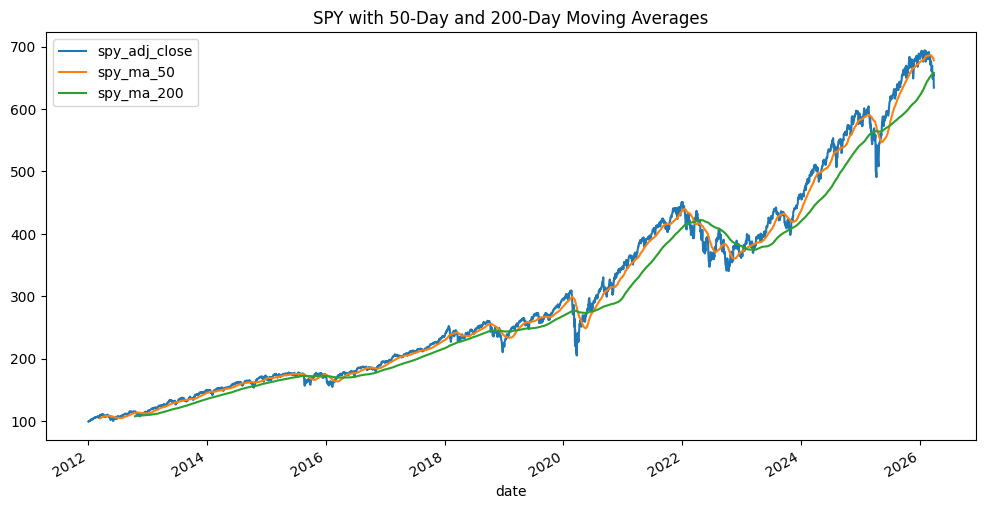

In [9]:
features_df[["spy_adj_close", "spy_ma_50", "spy_ma_200"]].plot(
    figsize=(12, 6),
    title="SPY with 50-Day and 200-Day Moving Averages",
)

In [10]:
features_df["spy_trend_signal"].value_counts(dropna=False)

spy_trend_signal
1.0    2846
0.0     534
NaN     199
Name: count, dtype: int64

The moving average crossover provides a simple and interpretable way to distinguish
between bullish and bearish market environments, without relying on complex modelling.

## 2.4 Realized Volatility

Volatility is a key component of market regimes.

Periods of low volatility are typically associated with stable, risk-on environments,
while spikes in volatility often coincide with stress events or market corrections.

I compute annualized realized volatility over:
- 20 trading days (short-term)
- 60 trading days (medium-term)

This allows comparison between recent and more persistent volatility conditions.

<Axes: title={'center': 'SPY Realized Volatility (20D and 60D)'}, xlabel='date'>

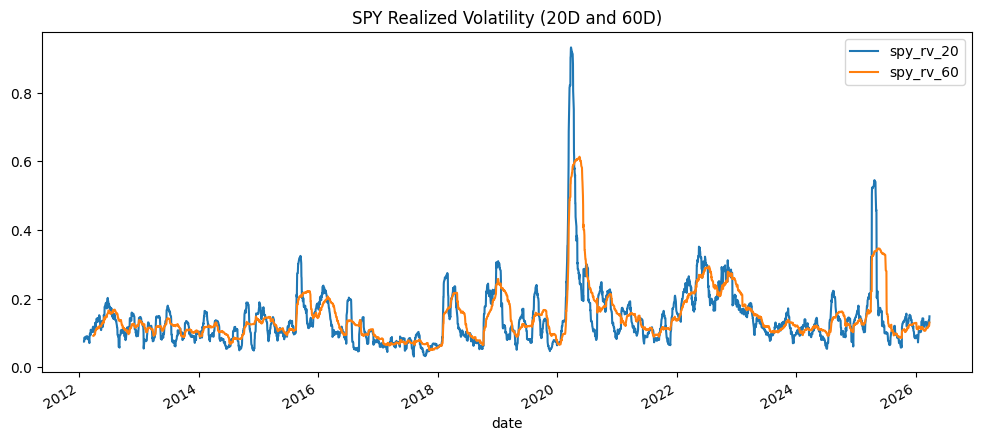

In [11]:
features_df[["spy_rv_20", "spy_rv_60"]].plot(
    figsize=(12, 5),
    title="SPY Realized Volatility (20D and 60D)",
)

Higher volatility levels will later be used as an indicator of potential stress
or transition regimes.

## 2.5 Drawdown

While volatility captures instability, it does not fully reflect cumulative losses.

Drawdown measures how far the market has fallen from its recent peak and is a useful
indicator of sustained stress.

I compute a trailing 252-day drawdown (approximately one year), which provides a
medium-term measure of market damage.

<Axes: title={'center': 'SPY Trailing Drawdown'}, xlabel='date'>

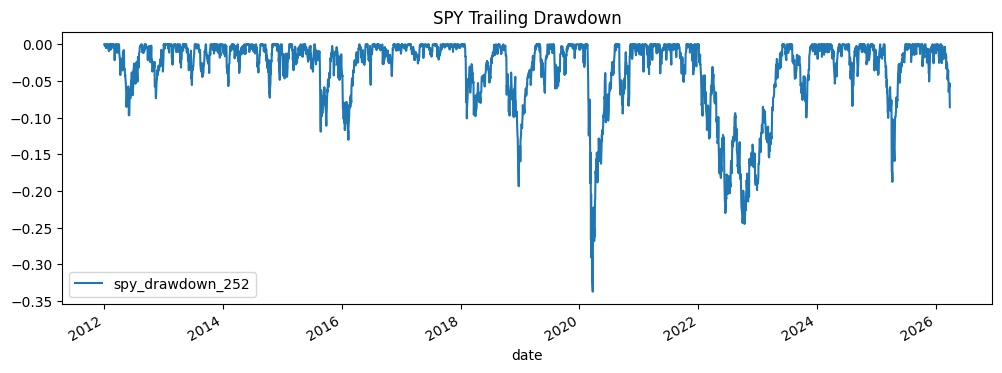

In [12]:
features_df[["spy_drawdown_252"]].plot(
    figsize=(12, 4),
    title="SPY Trailing Drawdown",
)

Drawdowns help distinguish between normal fluctuations and more severe market declines.

## 2.6 Macro and Risk Context

To complement price-based features, I include two simple macro indicators:

- **VIX (implied volatility)**:
  captures market expectations of future volatility and is often interpreted
  as a measure of fear or uncertainty.

- **Treasury yield changes**:
  reflect shifts in the interest rate environment, which can affect equity
  valuations and broader financial conditions.

These variables provide additional context beyond SPY price movements alone.

In [13]:
macro_cols = [col for col in ["vix_level", "vix_change_20", "tnx_change_20"] if col in features_df.columns]
features_df[macro_cols].tail()

,vix_level,vix_change_20,tnx_change_20
date,,,
2026-03-23,26.150000,0.244645,0.305
2026-03-24,26.950001,0.378517,0.359
2026-03-25,25.330000,0.412716,0.280
2026-03-26,27.440001,0.472893,0.399
2026-03-27,31.049999,0.563444,0.478


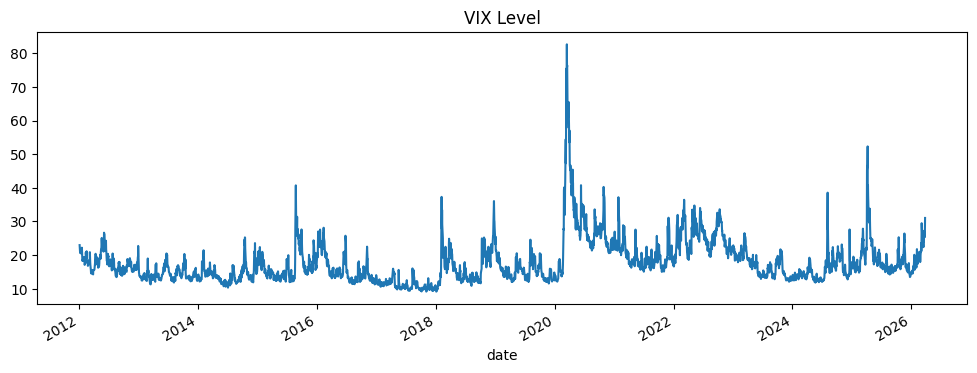

In [14]:
if "vix_level" in features_df.columns:
    features_df["vix_level"].plot(
        figsize=(12, 4),
        title="VIX Level",
    )

Movements in VIX are particularly useful for identifying transitions between
risk-on and risk-off environments.

## 2.7 Feature Stabilization

Because many features rely on rolling calculations, it is useful to remove
the initial warm-up period before further analysis.

This ensures that all key indicators are fully defined.

In [15]:
clean_features_df = drop_feature_warmup_rows(features_df)

print(f"Rows after warm-up: {clean_features_df.shape[0]}")
clean_features_df[available_feature_cols].head()

Rows after warm-up: 3380


,spy_ret_1d,spy_ma_50,spy_ma_200,spy_trend_signal,spy_rv_20,spy_rv_60,spy_drawdown_252,vix_level,vix_change_20,tnx_change_20
date,,,,,,,,,,
2012-10-16,0.010133,112.957231,107.607942,1.0,0.094059,0.108537,-0.006270,15.220000,0.073343,-0.092
2012-10-17,0.004535,113.061983,107.689297,1.0,0.095470,0.106720,-0.001764,15.070000,0.085735,0.029
2012-10-18,-0.002598,113.158055,107.768373,1.0,0.095955,0.107028,-0.004357,15.030000,0.068230,0.049
2012-10-19,-0.016665,113.213817,107.836518,1.0,0.112714,0.108778,-0.020949,17.059999,0.220315,0.008
2012-10-22,0.000140,113.266279,107.906028,1.0,0.112735,0.102518,-0.020812,16.620001,0.174558,0.080


## 2.8 Summary

At this stage, the feature set captures four core aspects of market behaviour:

1. **Trend** (moving averages)  
2. **Volatility** (realized volatility)  
3. **Stress** (drawdown)  
4. **Macro context** (VIX and interest rates)  

These features provide a structured and interpretable basis for defining market regimes.

The next step is to translate these indicators into a small number of discrete
regime labels.

# 3. Market Regime Classification

Using the engineered features, I classify each day into a discrete market regime.

The objective is not to predict short-term returns directly, but to organize market conditions into a small number of interpretable states that reflect trend, volatility, and market stress.

## 3.1 Regime Design

The regime classification is rule-based and intentionally designed to remain interpretable.

The four regimes are:

- **Risk-on**: positive trend with calm volatility conditions
- **Recovery**: positive trend, but volatility remains elevated and is improving
- **Stress**: negative trend or unstable market conditions without full capitulation
- **Risk-off**: severe stress, characterized by high implied volatility, deep drawdowns, or both

In addition to fixed thresholds such as VIX levels, the classification also uses rolling realized-volatility context so that current volatility can be judged relative to recent market history.

In [21]:
from src.regimes import (
    assign_regimes,
    get_known_regime_subset,
    get_regime_counts,
    get_regime_distribution,
    summarize_regime_returns,
)

ImportError: cannot import name 'get_known_regime_subset' from 'src.regimes' (C:\Users\User\git\personal_projects\market-regimes-trading-signals\market-regimes-trading-signals\src\regimes.py)

In [ ]:
regime_df = assign_regimes(clean_features_df)
regime_df.head()

In [ ]:
get_regime_counts(regime_df)

In [ ]:
get_regime_distribution(regime_df)

In [ ]:
summarize_regime_returns(regime_df)

In [ ]:
known_regime_df = get_known_regime_subset(regime_df)
known_regime_df.head()

## 3.2 Visual Inspection of Regimes

A useful first validation step is to compare the assigned regimes with the historical SPY path.

The aim is not to produce perfectly clean segmentation, but to check whether:
- risk-on dominates strong upward-trending markets
- recovery appears after stressed periods
- stress and risk-off cluster around major drawdowns and volatility spikes

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(known_regime_df.index, known_regime_df["spy_adj_close"], label="SPY")

colors = {
    "risk_on": "green",
    "recovery": "blue",
    "stress": "orange",
    "risk_off": "red",
}

for regime, color in colors.items():
    mask = known_regime_df["regime"] == regime
    ax.scatter(
        known_regime_df.index[mask],
        known_regime_df.loc[mask, "spy_adj_close"],
        color=color,
        s=5,
        label=regime,
    )

ax.legend()
ax.set_title("Market Regimes Over Time")
plt.show()